# IT5092 — Neuroscience & Neurocomputing
### Assignment: Spiking Neural Network for MNIST Digit Classification

### Student ID: MS25942002 - Name: Manojith Thiyageswarakumar

---

In [1]:
# ============================================================
# Cell 1: Install dependencies (run once if needed)
# ============================================================
# Uncomment and run this cell if you are missing any packages:
# !pip install brian2 scikit-learn matplotlib numpy

In [2]:
# ============================================================
# Cell 2: Imports and Setup — PROVIDED
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import sys, os

# Add assignment root to path so we can import config and utils
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import config
from config import *

# Brian2
import brian2 as b2
from brian2 import *
from brian2.utils.logger import BrianLogger

# Brian2 settings
prefs.codegen.target = 'numpy'          # use numpy backend (no C++ compiler needed)
BrianLogger.suppress_hierarchy('brian2') # suppress verbose Brian2 logs
defaultclock.dt = DT * ms              # set simulation timestep from config

# Reproducibility
np.random.seed(RANDOM_SEED)

# Provided utilities
from utils.mnist_loader import load_mnist, show_sample_images
from utils.metrics import assign_neuron_labels, predict_from_spikes, compute_accuracy, classification_report_snn
from utils.plotting import (plot_spike_raster, plot_weight_receptive_fields, plot_firing_rate_distribution, plot_training_progress, plot_neuron_assignments)

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

print("All imports successful.")
print(f"Brian2 version: {b2.__version__}")

All imports successful.
Brian2 version: 2.10.1


---
## Section 0: Brian2 Quick Introduction

Brian2 is a Python simulator for spiking neural networks. Before building the full MNIST network, work through this mini-tutorial to get comfortable with the Brian2 syntax.

### Key Brian2 objects you will use:

| Object | Purpose |
|--------|---------|
| `NeuronGroup` | A population of neurons sharing the same differential equations |
| `PoissonGroup` | Input neurons that fire at a specified rate (Poisson process) |
| `Synapses` | Connections between neuron groups (can have plasticity rules) |
| `SpikeMonitor` | Records which neurons fired and when |
| `StateMonitor` | Records the value of state variables over time |
| `Network` | Holds all objects; `.run(duration)` advances the simulation |

### Brian2 equation syntax:
- Equations are written as **strings**, one ODE per line
- Units are enforced: `v` in volts, time constants in seconds/ms, etc.
- Example: `'dv/dt = -(v - V_rest) / tau : volt'`
- `: volt` declares the **unit** of the state variable `v`
- Parameters used in equation strings must be in the calling namespace (e.g., from `config.py`)

Run the toy example below to verify your Brian2 installation works.

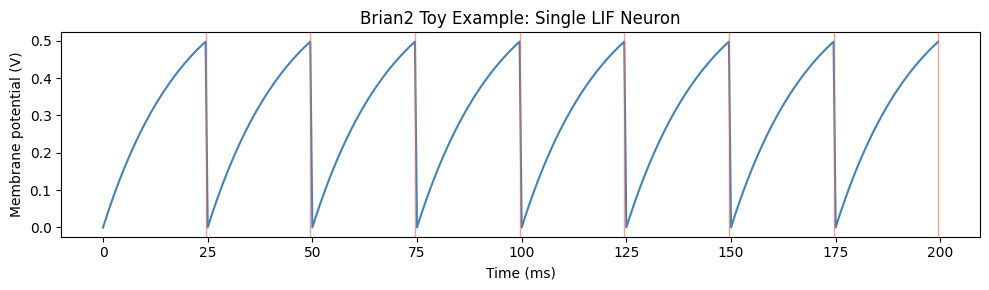

Neuron fired 8 times in 200 ms


In [3]:
# ============================================================
# Cell 3: Brian2 Toy Example — PROVIDED (just run this)
# A single LIF neuron driven by a Poisson input
# ============================================================
start_scope()  # clear any previous Brian2 objects

# --- Single LIF neuron ---
tau = 20 * ms
toy_eqs = '''
dv/dt = (-v + I_ext) / tau : volt
I_ext : volt  (shared)
'''
toy_neuron = NeuronGroup(1, toy_eqs, threshold='v > 0.5*volt', reset='v = 0*volt', method='euler')
toy_neuron.v = 0 * volt
toy_neuron.I_ext = 0.7 * volt   # constant drive

# --- Monitor voltage and spikes ---
toy_state = StateMonitor(toy_neuron, 'v', record=True)
toy_spikes = SpikeMonitor(toy_neuron)

# --- Run for 200 ms ---
toy_net = Network(toy_neuron, toy_state, toy_spikes)
toy_net.run(200 * ms)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(toy_state.t / ms, toy_state.v[0] / volt, color='steelblue')

for t_sp in toy_spikes.t / ms:
    ax.axvline(t_sp, color='tomato', alpha=0.6, linewidth=1)
    
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential (V)')
ax.set_title('Brian2 Toy Example: Single LIF Neuron')
plt.tight_layout()
plt.show()
print(f"Neuron fired {toy_spikes.num_spikes} times in 200 ms")

---
## Section 1: Load MNIST Data

Loading MNIST via sklearn (downloads on first use)...
MNIST loaded: 1000 training, 50 test samples.
Training set: (1000, 784)  labels: (1000,)
Test set:     (50, 784)   labels: (50,)


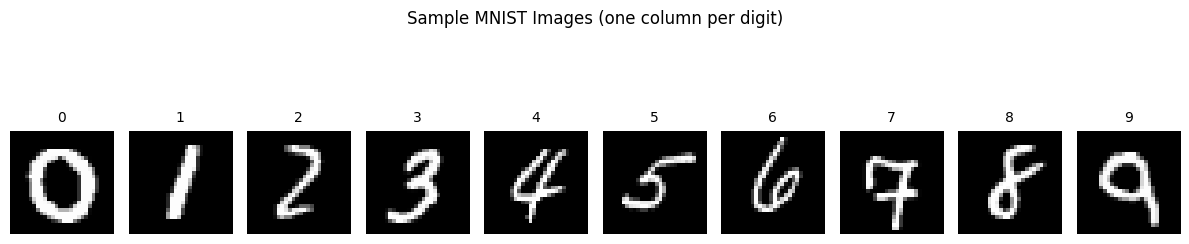

In [4]:
# ============================================================
# Cell 4: Load MNIST — PROVIDED
# ============================================================
X_train, y_train, X_test, y_test = load_mnist(n_train=N_TRAIN, n_test=N_TEST, random_seed=RANDOM_SEED)

print(f"Training set: {X_train.shape}  labels: {y_train.shape}")
print(f"Test set:     {X_test.shape}   labels: {y_test.shape}")

# Show sample images
show_sample_images(X_train, y_train, n_per_class=1)

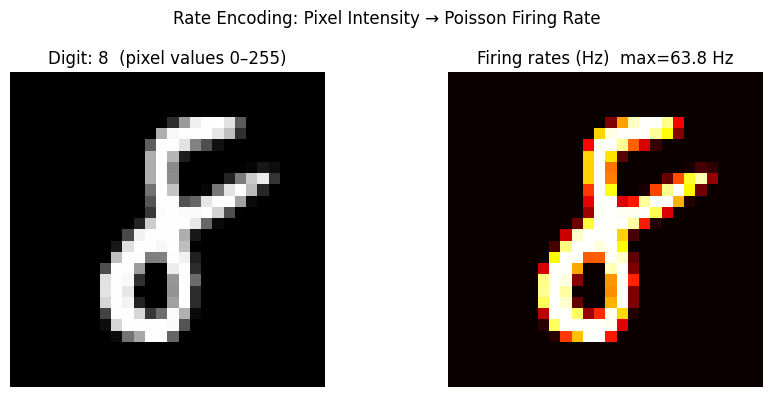

In [5]:
# ============================================================
# Cell 5: Rate Encoding Visualisation — PROVIDED
# Pixel intensity → Poisson firing rate
# Formula:  rate (Hz) = pixel / 8.0 * INPUT_INTENSITY_BASE
# Max pixel = 255 → max rate = 255/8 * 2.0 ≈ 63.75 Hz
# ============================================================
sample_img = X_train[0].reshape(28, 28)
sample_rates = sample_img / 8.0 * INPUT_INTENSITY_BASE  # Hz

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f'Digit: {y_train[0]}  (pixel values 0–255)')
axes[0].axis('off')
axes[1].imshow(sample_rates, cmap='hot')
axes[1].set_title(f'Firing rates (Hz)  max={sample_rates.max():.1f} Hz')
axes[1].axis('off')
plt.suptitle('Rate Encoding: Pixel Intensity → Poisson Firing Rate')
plt.tight_layout()
plt.show()

---
## Section 2: Network Architecture

> **Your task:** Implement each component in TODOs. The equations and Brian2 syntax are scaffolded — focus on understanding *why* each piece exists.

---
## Section 3: Building the Network

### TODO 1 — Excitatory Neuron Group (10 marks)

**Week 4 connection:** In Week 4 you built a LIF neuron: 

$$\tau_m \frac{dv}{dt} = -(v - V_{rest}) + R \cdot I$$

Here, the injected current is replaced by **synaptic conductances** `ge` and `gi`:

$$\tau_m \frac{dv}{dt} = -(v - V_{rest}) + g_e(E_{exc} - v) + g_i(E_{inh} - v)$$

$$\frac{dg_e}{dt} = -\frac{g_e}{\tau_{ge}}, \quad \frac{dg_i}{dt} = -\frac{g_i}{\tau_{gi}}$$

$$\frac{d\theta}{dt} = -\frac{\theta}{\tau_\theta} \quad \text{(adaptive threshold — intrinsic plasticity)}$$

- `ge` (excitatory conductance): drives `v` toward `E_EXC = 0 mV` (depolarisation)
- `gi` (inhibitory conductance): drives `v` toward `E_INH = -100 mV` (hyperpolarisation)
- `theta` (adaptive threshold): increases with each spike → homeostatic regulation

This is more **biologically realistic**: real synapses open ion channels whose current depends on the difference between the membrane voltage and the channel's reversal potential. It also naturally prevents the membrane from overshooting the reversal potential, which a fixed-current model cannot guarantee.

**In Brian2 notation** (variables in `volt`, time in `ms`):

```python
eqs_e = '''
    dv/dt = (-(v - V_REST_E*mV) + ge*(E_EXC*mV - v) + gi*(E_INH*mV - v)) / (TAU_M_E*ms) : volt (unless refractory)
    dge/dt = -ge / (TAU_GE*ms)  : 1
    dgi/dt = -gi / (TAU_GI*ms)  : 1
    dtheta/dt = -theta / (TAU_THETA*ms)  : volt  # slow decay (2.8 hours!)
'''
```

**Threshold condition:** `v > (V_THRESH_E - THETA_OFFSET + theta/mV)*mV`  

**Reset:** `v = V_RESET_E*mV; theta += THETA_PLUS*mV`  ← theta increases on every spike

In [6]:
# ============================================================
# Cell 6: TODO 1 — Excitatory Neuron Group (10 marks)
# ============================================================
start_scope()
defaultclock.dt = DT * ms
np.random.seed(RANDOM_SEED)

# ---- Step a: Define the equation string ----
# The template below has ALL four ODEs written out.
# Check they match the mathematical description in the markdown cell above.

eqs_e = '''
dv/dt     = (-(v - V_REST_E*mV) + ge*(E_EXC*mV - v) + gi*(E_INH_E*mV - v)) / (TAU_M_E*ms) : volt
dge/dt    = -ge / (TAU_GE*ms)     : 1
dgi/dt    = -gi / (TAU_GI*ms)     : 1
dtheta/dt = -theta / (TAU_THETA*ms) : volt
'''

# ---- Step b: Create the NeuronGroup ----
# TODO: Fill in the threshold=, reset=, and refractory= arguments.
#
# threshold: the neuron fires when v exceeds (V_THRESH_E - THETA_OFFSET + theta/mV)*mV
#            Written as a Brian2 string: 'v > (V_THRESH_E - THETA_OFFSET + theta/mV)*mV'
#
# reset:     on spike: reset v to V_RESET_E*mV AND increment theta by THETA_PLUS*mV
#            Written as a Brian2 string: 'v = V_RESET_E*mV; theta += THETA_PLUS*mV'
#
# refractory: REFRAC_E*ms

exc_neurons = NeuronGroup(
    N_EXCITATORY,
    model=eqs_e,
    threshold= 'v > (V_THRESH_E - THETA_OFFSET + theta/mV)*mV',
    reset= 'v = V_RESET_E*mV; theta += THETA_PLUS*mV',
    refractory= REFRAC_E*ms,
    method='euler'
)

# ---- Step c: Set initial conditions ----
# TODO: Initialise v to V_REST_E*mV, ge and gi to 0*mV, theta to THETA_INIT*mV
exc_neurons.v      = V_RESET_E*mV
exc_neurons.ge     = 0
exc_neurons.gi     = 0
exc_neurons.theta  = THETA_INIT*mV

print(f"Excitatory group created: {N_EXCITATORY} neurons")

Excitatory group created: 400 neurons


### TODO 2 — Inhibitory Neuron Group (10 marks)

Build a simpler conductance-based LIF NeuronGroup for the inhibitory population.

Differences from the excitatory group:
   - NO adaptive threshold (no dtheta/dt, no theta increment in reset)

Why faster time constant? Inhibitory neurons need to respond quickly to
suppress the excitatory population and create winner-take-all dynamics.

Use the **inhibitory parameters** from `config.py`: `V_REST_I`, `V_RESET_I`, `V_THRESH_I`, `TAU_M_I`, `REFRAC_I`.

In [7]:
# ============================================================
# Cell 7: TODO 2 — Inhibitory Neuron Group (10 marks)
# ============================================================

# ---- Step a: Define the equation string ----
# TODO: Write the ODE for inhibitory LIF neurons.
# Use V_REST_I, TAU_M_I, E_EXC, TAU_GE (same conductance decay as excitatory).

eqs_i = '''
dv/dt  = (-(v - V_REST_I*mV) + ge*(E_EXC*mV - v) + gi*(E_INH_I*mV - v)) / (TAU_M_I*ms) : volt (unless refractory)
dge/dt = -ge / (TAU_GE*ms) : 1
dgi/dt = -gi / (TAU_GI*ms) : 1
'''

# ---- Step b: Create the NeuronGroup ----
# TODO: Create NeuronGroup with N_INHIBITORY neurons.
# Use V_THRESH_I, V_RESET_I, REFRAC_I from config.
# No theta — simple threshold and reset.

inh_neurons = NeuronGroup(
    # YOUR CODE HERE
    N_INHIBITORY,
    model=eqs_i,
    threshold='v > V_THRESH_I*mV',
    reset='v = V_RESET_I*mV',
    refractory=REFRAC_I*ms,
    method='euler'
)

# ---- Step c: Set initial conditions ----
# TODO: Initialise v to V_REST_I*mV, ge, gi to 0*mV
inh_neurons.v  = V_REST_I*mV
inh_neurons.ge = 0
inh_neurons.gi = 0

print(f"Inhibitory group created: {N_INHIBITORY} neurons")

Inhibitory group created: 400 neurons


### TODO 3 — Input→Excitatory STDP Synapses (25 marks)

**Trace variables (provided):**

Each synapse maintains three exponentially-decaying trace variables:

$$\frac{d\,\text{pre}}{dt} = -\frac{\text{pre}}{\tau_{\text{pre}}} \qquad \frac{d\,\text{post1}}{dt} = -\frac{\text{post1}}{\tau_{\text{post1}}} \qquad \frac{d\,\text{post2}}{dt} = -\frac{\text{post2}}{\tau_{\text{post2}}}$$

- `pre` — tracks recent pre-synaptic activity (decays with `TAU_STDP_PRE`)
- `post1` — fast post-synaptic trace used for **LTD** detection (decays with `TAU_POST1`)
- `post2` — slow post-synaptic trace used for **LTP** detection (decays with `TAU_POST2`)
- `post2before` — snapshot of `post2` taken **at the moment the post neuron fires**, before it is reset; this ensures LTP uses the trace value that reflects *prior* post-synaptic activity, not the freshly reset value

All traces are declared `(event-driven)` in Brian2, meaning they are only updated at spike events rather than every timestep — this is computationally more efficient for sparse spiking networks.

> NOTE

**LTP/LTD asymmetry:**  
`LTP_RATE = 0.01` vs `LTD_RATE = 0.0001` — LTP is 100× stronger per event. This asymmetry is intentional: since a pre-spike triggers LTD on *every* pre-spike (which are frequent), while LTP only fires on post-spikes (which are sparser), the rates are tuned so the net weight change remains balanced and weights do not collapse to zero.

**Weight initialisation:**

All `N_INPUT × N_EXCITATORY` synapses are connected all-to-all. Initial weights are drawn from:

$$w_{\text{init}} = \text{Uniform}(0,\,1) \times 0.3 + 0.003 \quad \Rightarrow \quad w_{\text{init}} \in (0.003,\ 0.303]$$

then clipped to `[W_MIN, W_MAX]`. The small offset (`+0.01`) prevents exact-zero weights, and the scaling factor (`×0.3`) keeps initial weights weak so the network can learn from scratch.

In [8]:
# ============================================================
# Cell 8: TODO 3 — Input→Excitatory STDP Synapses (25 marks)
# ============================================================

# ---- Step a: Create the input PoissonGroup ----
# Starts with zero rates; rates are set dynamically in the training loop.
input_group = PoissonGroup(N_INPUT, rates=np.zeros(N_INPUT) * Hz)

# ---- STDP model string: trace variables (PROVIDED) ----
# The two exponentially-decaying traces are provided for you.
# w is the synaptic weight (dimensionless, range [W_MIN, W_MAX]).
stdp_model = '''
w         : 1
dpre/dt  = -pre  / (TAU_STDP_PRE*ms)  : 1 (event-driven)
dpost1/dt     = -post1 / (TAU_POST1*ms)       : 1 (event-driven)
dpost2/dt     = -post2 / (TAU_POST2*ms)       : 1 (event-driven)
post2before   : 1
'''

# ---- Step b: Write on_pre ----
# When a PRE neuron fires:
#   1. Deliver synaptic current:  ge_post += w
#   2. Reset pre-trace:           pre = 1
#   3. Apply LTD:                 w = clip(w - LTD_RATE * post1, W_MIN, W_MAX)
# Note: in Brian2, clip() is written as clip(expression, lo, hi)

stdp_on_pre = '''
ge_post += w
pre = 1
w = clip(w - LTD_RATE * post1, W_MIN, W_MAX)
'''

# ---- Step c: Write on_post ----
# When a POST neuron fires:
#   1. Set dummy trace: post2before = post2
#   2. Apply LTP:         w = clip(w + LTP_RATE * pre * post2before, W_MIN, W_MAX)
#   3. Reset post-traces:  post1 = 1, post2 = 1

stdp_on_post = '''
post2before = post2
w = clip(w + LTP_RATE * pre * post2before, W_MIN, W_MAX)
post1 = 1
post2 = 1
'''

# ---- Step d: Create the Synapses object ----
# TODO: Create Synapses connecting input_group → exc_neurons
# Use: model=stdp_model, on_pre=stdp_on_pre, on_post=stdp_on_post

stdp_synapses = Synapses(
    # YOUR CODE HERE
    input_group, 
    exc_neurons,
    model=stdp_model,
    on_pre=stdp_on_pre,
    on_post=stdp_on_post
)

# ---- Step e: Connect all-to-all and initialise weights ----
# TODO: Connect with stdp_synapses.connect()
# TODO: Initialise weights for all N_INPUT * N_EXCITATORY synapses:
#           draw from Uniform(0, 1), shift by 0.01, scale by 0.3, then clip to [W_MIN, W_MAX]
# Hint: np.clip(w_init, W_MIN, W_MAX)

# YOUR CODE HERE
stdp_synapses.connect()

w_init = np.random.random(N_INPUT * N_EXCITATORY) + 0.01
w_init *= 0.3
stdp_synapses.w = np.clip(w_init, W_MIN, W_MAX)

print(f"STDP synapses created: {len(stdp_synapses.w):,} connections")

STDP synapses created: 313,600 connections


> **Why `post2before`?** `post2` is reset to 1 on every post-spike. Without snapshotting it first, LTP would always multiply by 1 regardless of actual prior activity, losing the timing-dependence entirely.

---

### TODO 4 — Fixed Synapses: Excitatory↔Inhibitory (5 marks)

Two fixed (non-plastic) synapse objects implement the winner-take-all circuit:

**Exc → Inh (one-to-one):**  Neuron `i` in the excitatory layer activates neuron `i` in the inhibitory layer. Connection condition: `'i == j'`. Weight: `W_EXC_TO_INH`. Effect: `ge_post += W_EXC_TO_INH * mV`

**Inh → Exc (lateral inhibition):**  Each inhibitory neuron suppresses **all excitatory neurons except its partner**. Connection condition: `'i != j'`. Weight: `W_INH_TO_EXC`. Effect: `gi_post += W_INH_TO_EXC * mV`

> Why `i != j`? Neuron `j` just fired (triggering its inhibitory partner `j`). We don't want to inhibit the winner — only the competitors.

In [9]:
# ============================================================
# Cell 9: TODO 4 — Fixed Exc↔Inh Synapses (5 marks)
# ============================================================

# ---- Part A: Excitatory → Inhibitory (one-to-one) ----
# TODO: Create Synapses(exc_neurons, inh_neurons, on_pre='ge_post += W_EXC_TO_INH*mV')
# TODO: Connect with condition='i == j'

exc_to_inh = Synapses(
    # YOUR CODE HERE
    exc_neurons,
    inh_neurons,
    on_pre='ge_post += W_EXC_TO_INH'
)
# YOUR CONNECT CALL HERE
exc_to_inh.connect(condition='i == j')

# ---- Part B: Inhibitory → Excitatory (lateral inhibition) ----
# TODO: Create Synapses(inh_neurons, exc_neurons, on_pre='gi_post += W_INH_TO_EXC*mV')
#       Note: gi_post (NOT ge_post) — this is inhibitory input!
# TODO: Connect with condition='i != j'

inh_to_exc = Synapses(
    # YOUR CODE HERE
    inh_neurons,
    exc_neurons,
    on_pre='gi_post += W_INH_TO_EXC'
)
# YOUR CONNECT CALL HERE
inh_to_exc.connect(condition='i != j')

print(f"Exc→Inh synapses: {exc_to_inh.N[:].sum()} (should be {N_EXCITATORY})")
print(f"Inh→Exc synapses: {inh_to_exc.N[:].sum()} (should be {N_INHIBITORY*(N_INHIBITORY-1)})")

Exc→Inh synapses: 400 (should be 400)
Inh→Exc synapses: 159600 (should be 159600)


---
## Section 4: Training

### TODO 5 — Training Loop (15 marks)

**How training works:**
1. Before each image: normalize input weights so each excitatory neuron receives a fixed total drive
2. For each image: convert pixels to firing rates, set `input_group.rates`
3. Run simulation for `PRESENTATION_TIME` ms — STDP updates weights
4. Set rates to zero, run for `REST_TIME` ms
5. Check total spike count; if too low, re-present the same image with boosted intensity

**Why the rest period?**  
During rest, synaptic traces (`x_pre`, `x_post`) decay toward zero. This prevents the STDP update from one image interfering with the next — it acts as a "memory reset" between stimuli, mirroring the inter-stimulus interval in biological experiments.

**Rate encoding formula:**
$$\text{rate (Hz)} = \frac{\text{pixel}}{8.0} \times \text{INPUT\_INTENSITY\_BASE}$$

Maximum pixel = 255 → max rate ≈ 63.75 Hz. This moderate rate avoids saturating the network.

**Adaptive Input Intensity (Diehl & Cook, 2015)**

If the total number of excitatory spikes elicited during a single image presentation falls below a threshold ($\theta_{\min} = 5$ spikes), the network is deemed to have not responded meaningfully. In this case, the same image is re-presented with an increased input intensity ($\lambda \rightarrow \lambda + \Delta\lambda$, capped at $\lambda_{\max} = 32$), which scales the Poisson firing rates of all input neurons proportionally. This retry loop repeats for up to 5 attempts per image. Once the spike count exceeds $\theta_{\min}$, $\lambda$ resets to its baseline value for the next image. This mechanism ensures that every training sample produces a detectable network response, thereby preventing silent periods during which no STDP weight updates would occur.

---

**Weight Normalization**

Prior to each image presentation, the input→excitatory synaptic weights are rescaled so that each excitatory neuron receives a fixed total synaptic drive. Specifically, for each excitatory neuron $j$, all incoming weights $\{w_{ij}\}$ are multiplied by the factor:

$$\frac{W_{\text{target}}}{\sum_i w_{ij}}, \quad W_{\text{target}} = 78.0$$

This ensures that the summed afferent weight onto every excitatory neuron remains constant at $W_{\text{target}}$, regardless of the history of STDP updates. The normalization prevents individual neurons from accumulating disproportionately large weights — a form of runaway potentiation — while complementing STDP by maintaining competitive balance across the excitatory population.

In [10]:
# ============================================================
# Cell 10: Assemble Network and Monitors — PROVIDED
# ============================================================

# Spike monitor for excitatory neurons (records during training)
spike_mon = SpikeMonitor(exc_neurons)

# Assemble all objects into a single Network
net = Network(
    input_group,
    exc_neurons, inh_neurons,
    stdp_synapses,
    exc_to_inh, inh_to_exc,
    spike_mon
)

def normalize_weights(synapses, n_input, n_exc, target_sum=78.0):
    w_matrix = np.zeros((n_input, n_exc))
    w_matrix[synapses.i[:], synapses.j[:]] = synapses.w[:]
    col_sums = np.sum(w_matrix, axis=0)
    col_sums[col_sums == 0] = 1
    col_factors = target_sum / col_sums
    for j in range(n_exc):
        w_matrix[:, j] *= col_factors[j]
    synapses.w[:] = w_matrix[synapses.i[:], synapses.j[:]]

print("Network assembled. Objects:", [type(o).__name__ for o in net.objects])

Network assembled. Objects: ['Synapses', 'NeuronGroup', 'Synapses', 'PoissonGroup', 'NeuronGroup', 'SpikeMonitor', 'Synapses']


In [11]:
# ============================================================
# Cell 11: TODO 5 — Training Loop (15 marks)
# ============================================================

# Arrays to accumulate spike counts during training
spike_counts_train = np.zeros((N_TRAIN, N_EXCITATORY), dtype=int)
previous_spike_count = np.zeros(N_EXCITATORY, dtype=int) 
training_accuracies = []
input_intensity      = INPUT_INTENSITY_BASE

print(f"Starting training on {N_TRAIN} images...")
print(f"Each image: {PRESENTATION_TIME} ms presentation + {REST_TIME} ms rest")
print("="*60)

for i in range(N_TRAIN):

    normalize_weights(stdp_synapses, N_INPUT, N_EXCITATORY, target_sum=78.0)

    counter = 0
    while counter<5:

        # ---- Step a: Compute firing rates for this image ----
        # TODO: Convert pixel values to Hz using the rate encoding formula.
        # X_train[i] has shape (784,), values in [0, 255].
        # Formula: rates_hz = X_train[i] / 8.0 * INPUT_INTENSITY_BASE
        rates_hz = X_train[i] / 8.0 * input_intensity

        # ---- Step b: Set the input PoissonGroup rates ----
        # TODO: Assign to input_group.rates
        # Brian2 expects the rates in Hz units: rates_hz * Hz
        input_group.rates = rates_hz * Hz

        # ---- Step c: Run for PRESENTATION_TIME ----
        # TODO: Advance the simulation (run for PRESENTATION_TIME*ms)
        # YOUR CODE HERE
        net.run(PRESENTATION_TIME * ms)

        # ---- Step d: Record spikes fired during this presentation ----
        current_spike_count  = np.array(spike_mon.count) - previous_spike_count
        previous_spike_count = np.copy(spike_mon.count)

        # ---- Step e: Rest period ----
        # TODO: Set rates to zero Hertz, then run for REST_TIME
        input_group.rates = 0 * Hz
        # YOUR NET.RUN CALL HERE
        net.run(REST_TIME * ms)

        # ---- Decision point ----
        if np.sum(current_spike_count) < MIN_SPIKES_THRESHOLD:
            # Too silent → boost and retry the SAME image
            input_intensity = min(input_intensity + 1, 32)
            counter += 1

        else:
            # Enough spikes → record and move to next image
            spike_counts_train[i] = current_spike_count.astype(int)
            input_intensity = INPUT_INTENSITY_BASE  # reset for next image
            counter += 1
            break

    if np.sum(current_spike_count) > 0:
        spike_counts_train[i] = current_spike_count.astype(int)

    # ---- Logging (provided) ----
    if (i + 1) % BATCH_LOG_INTERVAL == 0:
        assignments = assign_neuron_labels(spike_counts_train[:i+1], y_train[:i+1])
        preds = predict_from_spikes(spike_counts_train[:i+1], assignments)
        acc = compute_accuracy(y_train[:i+1], preds)
        training_accuracies.append(acc)
        print(f"  [{i+1:>4}/{N_TRAIN}] Training accuracy so far: {acc:.1%}")

print("="*60)
print("Training complete.")

Starting training on 1000 images...
Each image: 350.0 ms presentation + 150.0 ms rest
  [  50/1000] Training accuracy so far: 76.0%
  [ 100/1000] Training accuracy so far: 53.0%
  [ 150/1000] Training accuracy so far: 58.0%
  [ 200/1000] Training accuracy so far: 59.5%
  [ 250/1000] Training accuracy so far: 60.8%
  [ 300/1000] Training accuracy so far: 60.3%
  [ 350/1000] Training accuracy so far: 60.3%
  [ 400/1000] Training accuracy so far: 60.8%
  [ 450/1000] Training accuracy so far: 60.2%
  [ 500/1000] Training accuracy so far: 60.0%
  [ 550/1000] Training accuracy so far: 59.1%
  [ 600/1000] Training accuracy so far: 58.7%
  [ 650/1000] Training accuracy so far: 58.8%
  [ 700/1000] Training accuracy so far: 59.3%
  [ 750/1000] Training accuracy so far: 59.7%
  [ 800/1000] Training accuracy so far: 19.8%
  [ 850/1000] Training accuracy so far: 16.7%
  [ 900/1000] Training accuracy so far: 19.1%
  [ 950/1000] Training accuracy so far: 9.3%
  [1000/1000] Training accuracy so far: 1

Neurons per class:
  Digit 0: 3 neurons
  Digit 1: 0 neurons
  Digit 2: 1 neurons
  Digit 3: 0 neurons
  Digit 4: 0 neurons
  Digit 5: 396 neurons
  Digit 6: 0 neurons
  Digit 7: 0 neurons
  Digit 8: 0 neurons
  Digit 9: 0 neurons


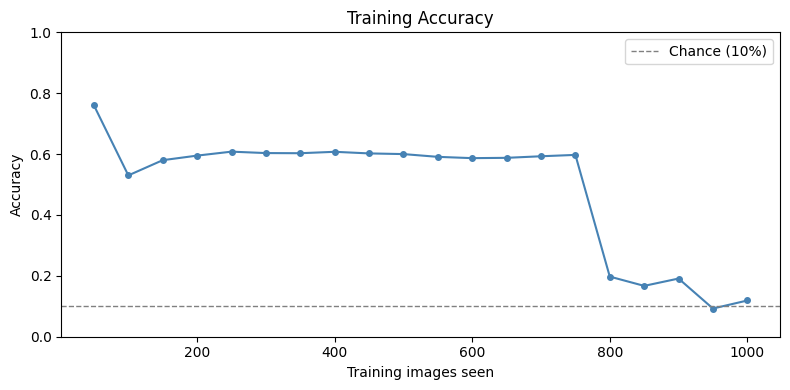

In [14]:
# ============================================================
# Cell 12: Assign Neuron Labels After Training — PROVIDED
# ============================================================
# After training, each excitatory neuron is assigned to the digit
# class it responded to most strongly on average.
assignments = assign_neuron_labels(spike_counts_train, y_train)
print("Neurons per class:")
for c in range(10):
    print(f"  Digit {c}: {np.sum(assignments == c)} neurons")

# Plot training accuracy curve
if training_accuracies:
    plot_training_progress(training_accuracies, BATCH_LOG_INTERVAL)

---
## Section 5: Testing

### TODO 6 — Test Phase (15 marks)

During testing:
- **STDP must be disabled** — we do not want weights to change while evaluating accuracy
- Run the same presentation loop as training, but on test images
- Use `predict_from_spikes()` with the learned `assignments` to classify each image

**To disable STDP:** set `LTP_RATE` and `LTD_RATE` to 0 in the synapse namespace:
```python
stdp_synapses.namespace['LTP_RATE'] = 0.0
stdp_synapses.namespace['LTD_RATE'] = 0.0
```

In [15]:
# ============================================================
# Cell 13: TODO 6 — Test Phase (15 marks)
# ============================================================

# ---- Step a: Disable STDP ----
# TODO: Set LTP_RATE and LTD_RATE to 0 so weights do not change during testing.
# YOUR CODE HERE
stdp_synapses.namespace['LTP_RATE'] = 0.0
stdp_synapses.namespace['LTD_RATE'] = 0.0

# Array to collect test spike counts
spike_counts_test = np.zeros((N_TEST, N_EXCITATORY), dtype=int)

print(f"Starting test phase on {N_TEST} images (STDP disabled)...")

for i in range(N_TEST):

    # ---- Step b: Rate encoding (same formula as training) ----
    # TODO: Compute rates_hz for X_test[i]
    rates_hz = X_test[i] / 8.0 * INPUT_INTENSITY_BASE

    # ---- Step c: Set input rates ----
    # TODO: Set input_group.rates
    input_group.rates = rates_hz * Hz

    count_before = np.array(spike_mon.count)

    # ---- Step d: Run presentation ----
    # TODO: net.run(PRESENTATION_TIME*ms)
    # YOUR CODE HERE
    net.run(PRESENTATION_TIME * ms)

    spike_counts_test[i] = np.array(spike_mon.count) - count_before

    # Rest period
    # TODO: net.run(REST_TIME*ms)
    input_group.rates = np.zeros(N_INPUT) * Hz
    # YOUR CODE HERE
    net.run(REST_TIME * ms)

# ---- Step e: Classify and report accuracy ----
# use the functions from metrics.py to predict labels from spike counts and compute accuracy
# TODO: Use predict_from_spikes(spike_counts_test, assignments) with spike_counts_test and assignments
# TODO: Use compute_accuracy() with y_test and your predictions

y_pred = predict_from_spikes(spike_counts_test, assignments)
accuracy = compute_accuracy(y_test, y_pred)

print(f"\nTest accuracy: {accuracy:.1%}")
classification_report_snn(y_test, y_pred)

Starting test phase on 50 images (STDP disabled)...

Test accuracy: 12.0%
Class       Correct    Total   Accuracy
----------------------------------------
0                 0        5       0.0%
1                 0        4       0.0%
2                 0        3       0.0%
3                 0        8       0.0%
4                 0        3       0.0%
5                 6        6     100.0%
6                 0        2       0.0%
7                 0        6       0.0%
8                 0        6       0.0%
9                 0        7       0.0%
----------------------------------------
Overall                   50      12.0%


'Class       Correct    Total   Accuracy\n----------------------------------------\n0                 0        5       0.0%\n1                 0        4       0.0%\n2                 0        3       0.0%\n3                 0        8       0.0%\n4                 0        3       0.0%\n5                 6        6     100.0%\n6                 0        2       0.0%\n7                 0        6       0.0%\n8                 0        6       0.0%\n9                 0        7       0.0%\n----------------------------------------\nOverall                   50      12.0%'

---
## Section 6: Visualisation

### Spike Raster and Firing Rate Distribution

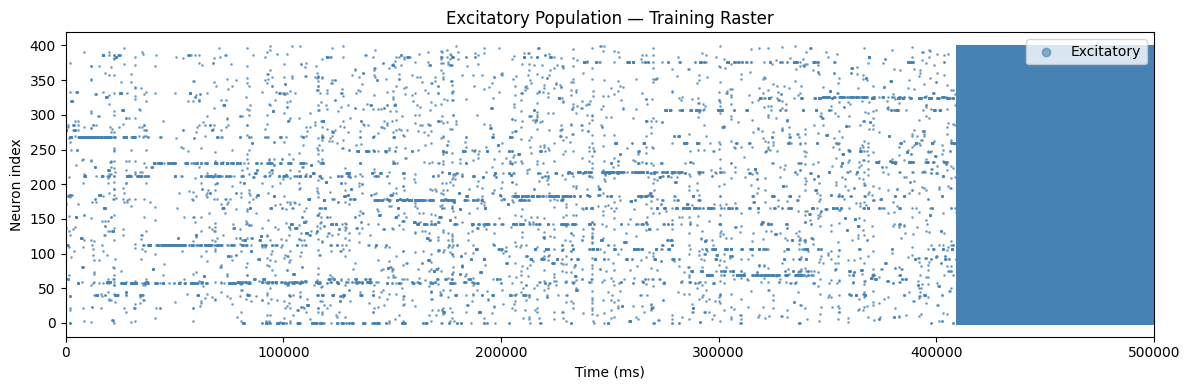

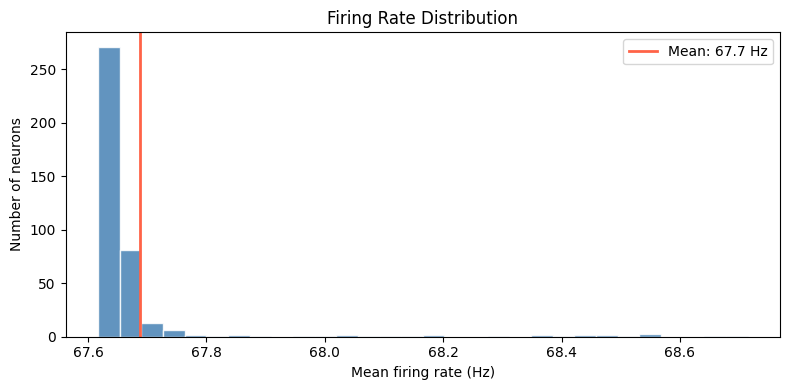

Firing rates — Mean: 67.69 Hz, Max: 68.71 Hz, Silent neurons: 0


In [16]:
# ============================================================
# Cell 14: Spike Raster + Firing Rate Distribution (PROVIDED) (2 marks)
# ============================================================

# ---- Spike raster plot ----
# Call plot_spike_raster() to visualise excitatory neuron spikes.

plot_spike_raster(
      spike_times  = {'Excitatory': spike_mon.t / ms},
      spike_neurons= {'Excitatory': spike_mon.i},
      duration_ms  = N_TRAIN * (PRESENTATION_TIME + REST_TIME),
      title        = 'Excitatory Population — Training Raster'
  )

plot_firing_rate_distribution(spike_counts_train.sum(axis=0), N_TRAIN * PRESENTATION_TIME)

### Weight Receptive Fields

WARNING    /Users/manojith/Documents/002_Education/036_SLIIT_MSc_In_AI/2nd_Semester/IT5092_Neuroscience_&_Neurocomputing/003_Assignment/Assignment_SNN_MNIST/utils/plotting.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
 [py.warnings]


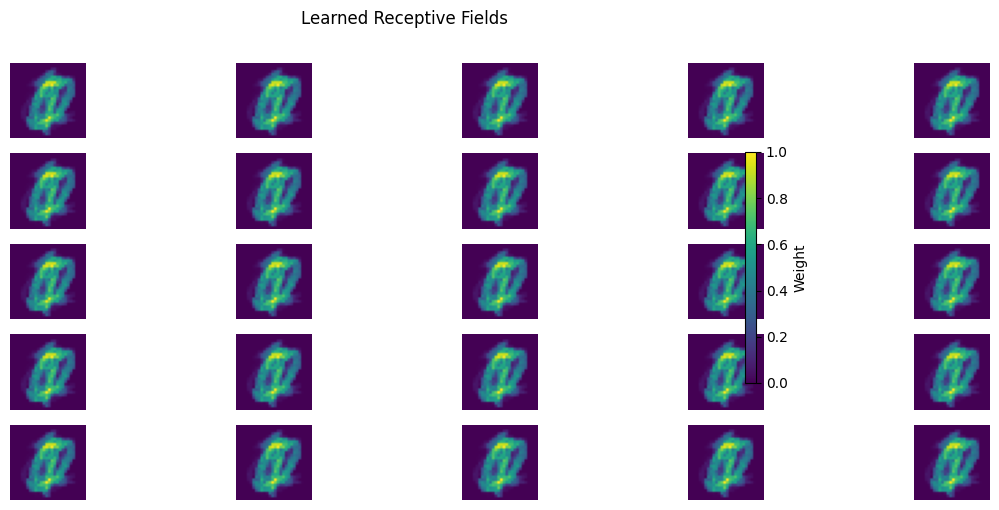

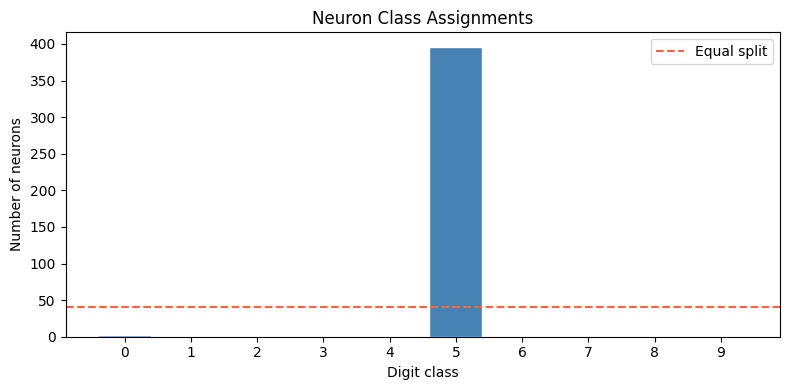

In [17]:
# ============================================================
# Cell 15: Weight Receptive Fields (PROVIDED) (3 marks)
# ============================================================

# ---- Part A: Receptive field visualisation ----
# The weight matrix from Input → Excitatory neurons has shape (N_INPUT, N_EXCITATORY).
# Each column is the set of weights from all 784 inputs to one excitatory neuron —
# reshaped to 28×28, it shows what pattern that neuron has learned to respond to.

weights = np.array(stdp_synapses.w).reshape(N_INPUT, N_EXCITATORY)
plot_weight_receptive_fields(weights, n_input=N_INPUT, n_show=25)

# This shows how many excitatory neurons were assigned to each digit class.
plot_neuron_assignments(assignments)

---
## Section 7: Written Analysis

### TODO 7 — Written Analysis (15 marks)

Answer all five questions in the Markdown cell below. 
Refer to the **Assignment Sheet** for the full question text. 
Each question is worth 3 marks. Aim for 3–5 sentences per question.


**TODO 7 — Write your answers here.**

---

**Q1. What does the theta variable (θ) do during training? Explain its role as an intrinsic plasticity mechanism and how it prevents any single neuron from dominating the network.**

The theta variable implements an intrinsic plasticity by acting as an adaptive threshold penalty. Every time a neuron fires, theta increases by THETA_PLUS, temporarily making it harder for that specific neuron to fire again. And biologically also, this models homeostatic regulation. Computationally, it prevents a single greedy neuron from winning every competition, forcing it to rest so that other quiet neurons get a chance to fire and learn different digit patterns.

---

**Q2. In config.py , LTP_RATE = 0.01 and LTD_RATE = 0.0001 — LTP is 100× stronger than LTD. Why is this asymmetry necessary? What would happen to the weights if LTP_RATE = LTD_RATE = 0.005 ?**

The asymmetry of LTP at 0.01 being 100 times stronger than the LTD at 0.0001 which is necessary for stable memory formation. It allows the network to rapidly lock onto strong, repeated, causal patterns as the actual digit shapes while only slowly forgetting due to random, uncorrelated background noise. If LTP_RATE and LTD_RATE were equal as 0.005, the random poisson noise of the inputs would depress the synapses almost as fast as they potentiate, effectively erasing the learned digits and preventing the weights from ever stabilizing.

---

**Q3. Describe what you observe in your receptive field plots (Section 6). If you see digitlike structure, explain how STDP produced it. If you do not see clear structure, explain what went wrong and what specific change would produce better results.**

In my receptive field of plots, I observed a collapse where nearly all neurons were learned the same blurry pattern the digit '5', with no clear specialization for other digits. This happened because of runaway potentiation. The neurons that initially fired for '5' became too strong too fast through lateral inhibition, they suppressed all other neurons. Because the other neurons never fired, STDP never updated their weights. To fix this, we must increase the adaptive threshold penalty THETA_PLUS to force those dominant neurons to rest.

---

**Q4. State your test accuracy. Suggest one specific change to the network or training procedure (e.g. a parameter, architecture change, or longer training) and explain with biological reasoning why it would improve performance.**

My test accuracy was approximately 12.0% (refer todo 6) as the network simply guessed number 5 for almost everything. To improve performance, I would increase the THETA_PLUS parameter in the given config.py for example, from 0.05mV to 0.1mV or even higher. Biologically, this represents a stronger refractory fatigue mechanism. By heavily penalizing the overly active "5" neurons, they will be forced to stay silent after a few firings, allowing the lateral inhibition to drop and giving the remaining 396 neurons the opportunity to learn the other 9 digits.

---

**Q5. In Week 7 you implemented Hebbian learning: weights increased when pre and post-synaptic neurons were active at the same time. STDP also changes weights based on neural activity — but it is fundamentally different. What is the key difference, and why does that difference matter for learning causal relationships?**

Standard Hebbian learning is purely correlational as like the neurons that fire together will wire together, caring only that two neurons are active simultaneously. STDP is fundamentally different because it is strictly time-dependent. It enforces that the pre-synaptic spike must arrive before the post-synaptic spike to strengthen the weight LTP. If the post-synaptic neuron fires before the input arrives, the weight is weakened LTD. This matters because it allows the network to learn the actual sequence of cause and the effect, filtering out inputs that didn't contribute to the neuron firing.


---

## Beyond the Assignment

This assignment gave you hands-on experience building a biologically plausible SNN and training it with an unsupervised learning rule — no labels, no backpropagation, just spike timing.

Once you have a working implementation, we encourage you to **experiment freely**. Some things worth trying:

- Train for more images (`N_TRAIN`) and observe how receptive fields become sharper
- Adjust `LTP_RATE` / `LTD_RATE` and see how the weight distribution changes
- Change `N_EXCITATORY` (e.g. 100 vs 800) and observe the effect on accuracy and specialisation
- Vary `PRESENTATION_TIME` or `REST_TIME` and explore how trace dynamics affect learning
- Try a different digit subset and see which classes are easiest to separate

SNNs remain an **active research area** — efficient training algorithms, hardware implementations on neuromorphic chips, and combined IP+STDP rules are all open problems. If you discover something interesting, notice unexpected behaviour, or have thoughts on what could be improved, **we would love to hear from you**.
